# Checkpoint 5: Visualization
### Dataset: house_sale.csv

Goal: Run three types of visualization on the df_clean prepared in the previous checkpoints: distribution graphs, a correlation heatmap, categorical breakdown. After each chart I write a short "what am I seeing" observation.

## 1. Restoring the df_clean

In [61]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 70)
sns.set_style("whitegrid")

In [62]:
df = pd.read_csv('house_sale.csv')
df

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...

In [63]:
df_clean = df.copy()

In [64]:
df_clean = df_clean.drop(columns=["Binanın növü", "hour_y"])
df_clean["featured_flag"] = df_clean["featured"].notnull()
df_clean["vip_flag"] = df_clean["vip"].notnull()

In [65]:
df_clean["mortgage_flag"] = df_clean["mortgage"].notnull()
df_clean["bill_of_sale_flag"] = df_clean["Çıxarış"].str.strip().str.lower().map({"var": 1, "yoxdur": 0})
df_clean = df_clean.drop(columns=["featured", "vip", "mortgage", "İpoteka", "bill_of_sale", "Çıxarış", "repair"])
df_clean["Təmir"] = df_clean["Təmir"].fillna("Unknown")

In [66]:
def seller_type(row):
    if pd.notnull(row["shop_name"]):
        return "Agency"
    elif pd.notnull(row["owner_name"]):
        return "Individual"
    return "Unknown"

In [67]:
df_clean["seller_type"] = df_clean.apply(seller_type, axis=1)
for col in ["shop_name", "shop_title", "owner_name", "owner_title"]:
    df_clean[col] = df_clean[col].fillna("N/A")
df_clean["products_label"] = df_clean["products_label"].fillna("Regular listing")
df_clean["description"] = df_clean["description"].fillna("")


In [68]:
def parse_area(val):
    if pd.isnull(val):
        return np.nan
    val = val.strip()
    if "sot" in val:
        return float(val.replace("sot", "").strip().replace(",", ".")) * 100
    return float(val.replace("m²", "").strip().replace(" ", ""))

In [69]:
df_clean["Sahə_numeric"] = df_clean["Sahə"].apply(parse_area)
df_clean["unit_price_calculated"] = (df_clean["price"] / df_clean["Sahə_numeric"]).round(2)
df_clean = df_clean.drop(columns=["unit_price"])

In [70]:
applicable_categories = ["Köhnə tikili", "Yeni tikili", "Ofis", "Həyət evi/Bağ evi"]
mask = df_clean["Kateqoriya"].isin(applicable_categories)
medians = df_clean.loc[mask].groupby("Kateqoriya")["Otaq sayı"].median()

In [71]:
for cat, med in medians.items():
    idx = df_clean[(df_clean["Kateqoriya"] == cat) & (df_clean["Otaq sayı"].isnull())].index
    df_clean.loc[idx, "Otaq sayı"] = med

In [72]:
df_clean = df_clean[df_clean["price"] >= 1000].copy()

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

In [73]:
def cap_grouped(df, col, group_col="Kateqoriya", k = 1.5):
    capped = df[col].copy()
    flag = pd.Series(False, index = df.index)
    for cat, group in df.groupby(group_col):
        low, high = iqr_bounds(group[col].dropna(), k)
        idx = group.index
        below = df.loc[idx, col] < low
        above = df.loc[idx, col] > high
        flag.loc[idx[below | above]] = True
        capped.loc[idx[below]] = low
        capped.loc[idx[above]] = high
    return capped, flag

In [74]:
df_clean["price_capped"], df_clean["is_outlier_price"] = cap_grouped(df_clean, "price")
df_clean["Sahə_numeric_capped"], df_clean["is_outlier_area"] = cap_grouped(df_clean, "Sahə_numeric")
df_clean["unit_price_capped"], df_clean["is_outlier_unit_price"] = cap_grouped(df_clean, "unit_price_calculated")

In [75]:
low_v, high_v = iqr_bounds(df_clean["views"])
df_clean["views_capped"] = df_clean["views"].clip(low_v, high_v)

In [76]:
floor_split = df_clean["Mərtəbə"].str.split("/", expand=True)
df_clean["floor_current"] = pd.to_numeric(floor_split[0].str.strip(), errors = "coerce")
df_clean["floor_total"] = pd.to_numeric(floor_split[1].str.strip(), errors = "coerce")
df_clean["floor_ratio"] = (df_clean["floor_current"] / df_clean["floor_total"]).round(2)
df_clean["is_top_floor"] = df_clean["floor_current"] == df_clean["floor_total"]
df_clean["is_ground_floor"] = df_clean["floor_current"] == 1

In [77]:
def loc_type(loc):
    if pd.isnull(loc):
        return "Unknown"
    match = re.search(r"\s(r|m|q)\.$", loc.strip())
    mapping = {"r": "District center", "m": "Near metro", "q": "Settlement"}
    return mapping.get(match.group(1), "Other") if match else "Other"


In [78]:
df_clean["location_type"] = df_clean["location"].apply(loc_type)

In [79]:
df_clean["price_per_room"] = np.where(
    df_clean["Otaq sayı"] > 0, (df_clean["price_capped"] / df_clean["Otaq sayı"]).round(0), np.nan)

In [80]:
category_median = df_clean.groupby("Kateqoriya")["price_capped"].transform("median")
df_clean["price_index_vs_category"] = (df_clean["price_capped"] / category_median).round(2)

In [81]:
print("df_clean is ready:", df_clean.shape)

df_clean is ready: (100765, 63)


## 2. Distribution graphs

Looking at the distribution of the key numeric columns: price_capped, Sahə_numeric_capped (area), unit_price_capped (price).

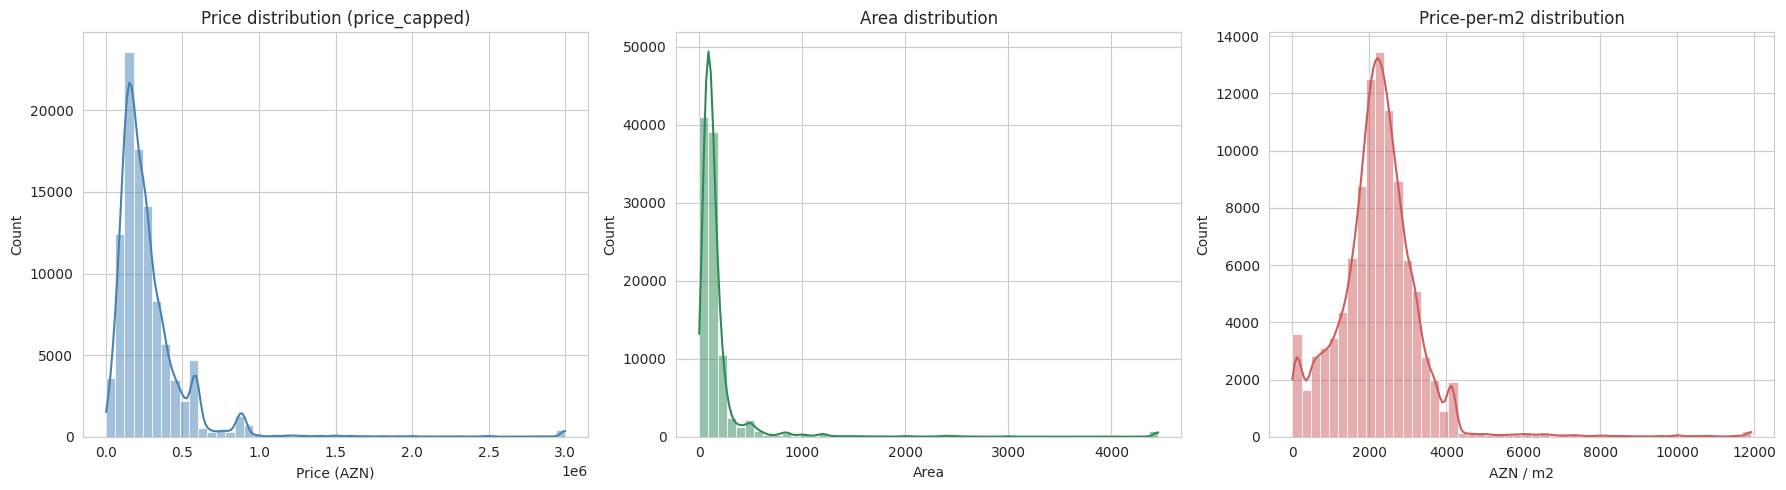

In [82]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

sns.histplot(df_clean["price_capped"], bins = 50, kde = True, ax = axes[0], color = "steelblue")
axes[0].set_title("Price distribution (price_capped)")
axes[0].set_xlabel("Price (AZN)")

sns.histplot(df_clean["Sahə_numeric_capped"], bins = 50, kde = True, ax = axes[1], color = "seagreen")
axes[1].set_title("Area distribution")
axes[1].set_xlabel("Area")

sns.histplot(df_clean["unit_price_capped"], bins = 50, kde = True, ax = axes[2], color = "indianred")
axes[2].set_title("Price-per-m2 distribution")
axes[2].set_xlabel("AZN / m2")

plt.tight_layout()
plt.show()


Even after capping, all three distributions remain right-skewed, normal for a real-estate market. The bulk of price_capped falls in the 100,000–400,000 AZN range, while Sahə_numeric_capped peaks in the 50–150 m2 range, consistent with a standard apartment size in the Baku market.

## 3. Correlation heatmap

Visualizing the correlation matrix to see the linear relationships among the numeric columns. I include the price_per_room, price_index_vs_category, floor_ratio to check whether they have a genuine relationship with price.

In [83]:
numeric_cols = [
    "price_capped", "Sahə_numeric_capped", "unit_price_capped",
    "Otaq sayı", "views_capped", "floor_ratio",
    "price_per_room", "price_index_vs_category"
]

corr = df_clean[numeric_cols].corr()

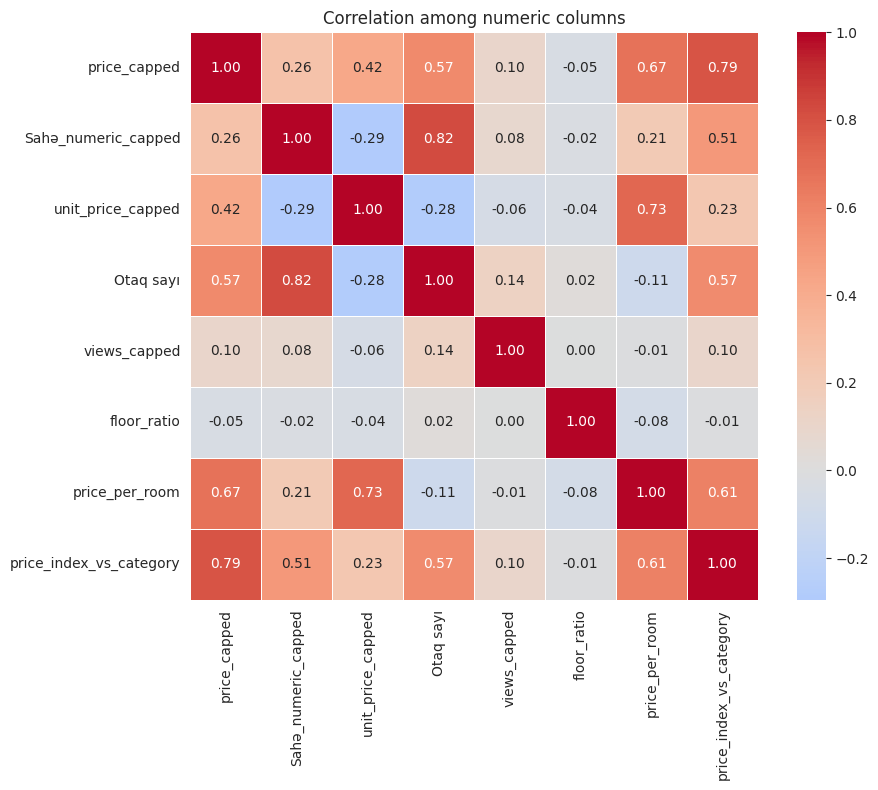

In [84]:
plt.figure(figsize = (10, 8))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0, square = True, linewidths = 0.5)
plt.title("Correlation among numeric columns")
plt.tight_layout()
plt.show()

The strongest positive correlation with price_capped is with price_index_vs_category (0.79) and price_per_room (0.67). Expected, since both are directly derived from price_capped.

Otaq sayı (room count) has a moderate positive correlation with price_capped (0.57), more rooms generally means a higher price, which makes sense.

The correlation between Sahə_numeric_capped (area) and price_capped is weaker than expected (0.26), likely because different categories have very different area-to-price ratios.

floor_ratio shows almost no relationship (-0.05), floor position alone doesn't strongly affect price; it would need to be examined together with other factors.

views_capped's relationship with price is very weak (0.10), view count reflects a listing's popularity, not its price.

## 4. Categorical breakdown

Showing how Kateqoriya (property category) breaks down both by listing count and by price.

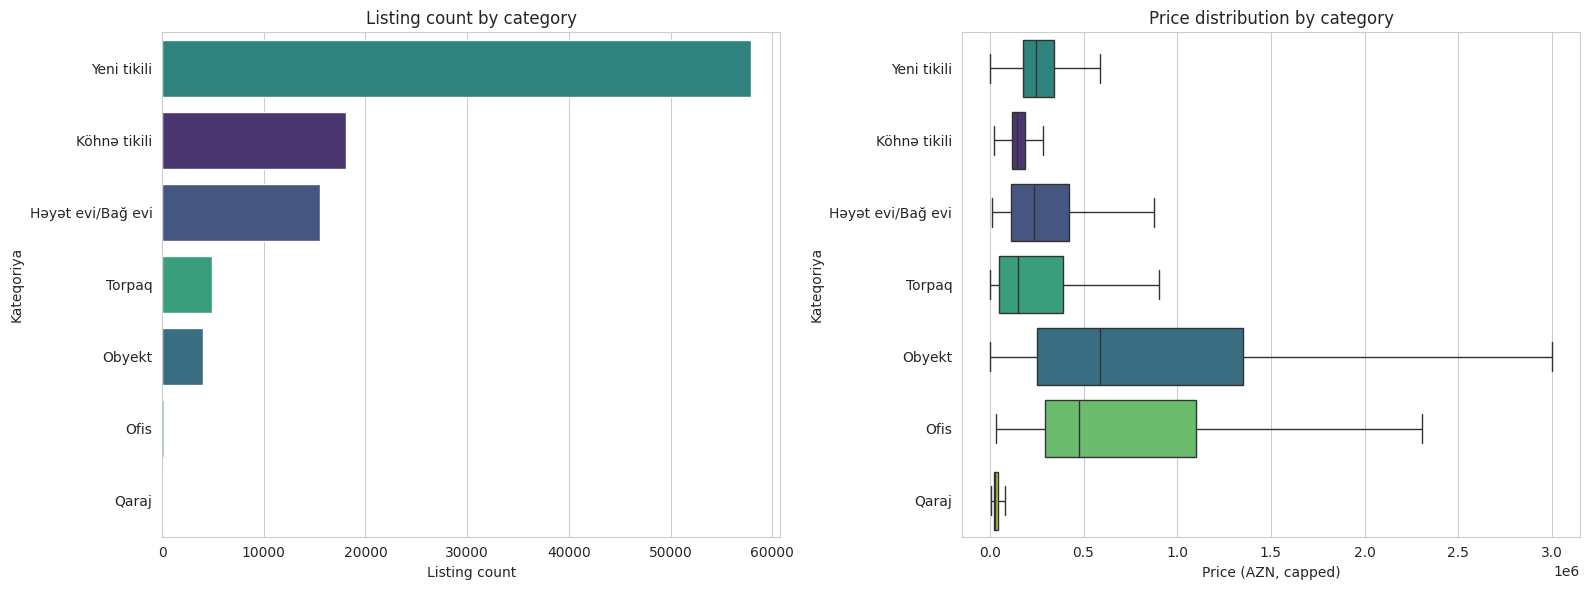

In [85]:
order = df_clean["Kateqoriya"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data = df_clean, y = "Kateqoriya", order = order, ax = axes[0], hue = "Kateqoriya", legend = False, palette = "viridis")
axes[0].set_title("Listing count by category")
axes[0].set_xlabel("Listing count")

sns.boxplot(data = df_clean, x="price_capped", y = "Kateqoriya", order = order, ax = axes[1], hue = "Kateqoriya", legend = False, palette = "viridis")
axes[1].set_title("Price distribution by category")
axes[1].set_xlabel("Price (AZN, capped)")

plt.tight_layout()
plt.show()


The vast majority of listings fall under "Yeni tikili" (new-construction apartments, 57%) and "Köhnə tikili" (older apartments, 18%). By price, "Obyekt" (commercial) has the widest spread and the highest median price, while "Qaraj" (garage), as expected, sits at the lowest price segment.

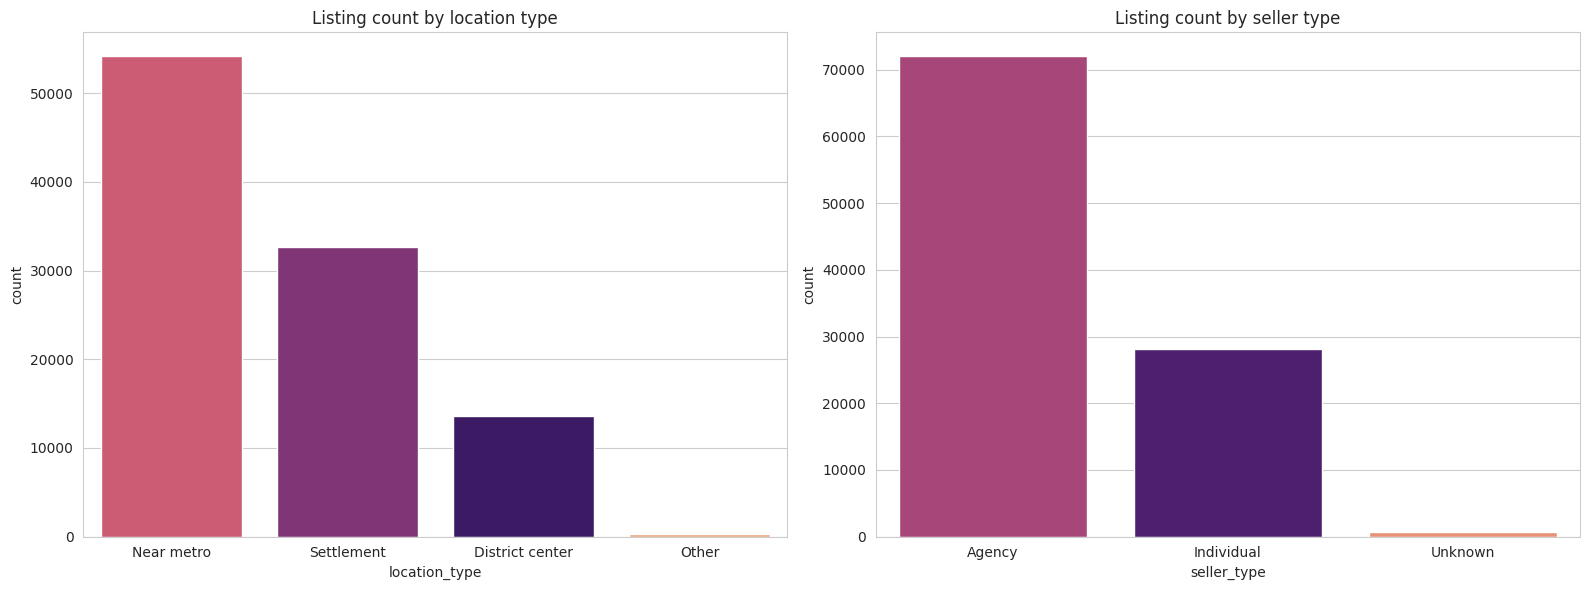

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data = df_clean, x = "location_type", order = df_clean["location_type"].value_counts().index, ax = axes[0], hue = "location_type", legend = False, palette = "magma")
axes[0].set_title("Listing count by location type")

sns.countplot(data = df_clean, x = "seller_type", order = df_clean["seller_type"].value_counts().index, ax = axes[1], hue = "seller_type", legend = False, palette = "magma")
axes[1].set_title("Listing count by seller type")

plt.tight_layout()
plt.show()


In [87]:
print("seller_type share within each location_type:")
print(pd.crosstab(df_clean["location_type"], df_clean["seller_type"], normalize = "index").round(3))


seller_type share within each location_type:
seller_type      Agency  Individual  Unknown
location_type                               
District center   0.801       0.190    0.008
Near metro        0.780       0.215    0.005
Other             0.322       0.678    0.000
Settlement        0.574       0.418    0.009


Most listings are in Near metro - type locations (54%), while Settlement holds a surprisingly large share (32%) - indicating an active construction/sales market in Baku's surrounding settlements. By seller type, Agency accounts for the majority of listings (about 72,000) compared to Individual sellers (about 28,000). The crosstab shows that individual sellers have a relatively higher share in Settlement listings (42%) than in District center (19%) or Near metro (21%) locations, but agencies still make up the majority even in settlements (57%).